In [1]:
import cv2
import os
import json
import random
import requests
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from dotenv import load_dotenv

load_dotenv()
HF_TOKEN = os.getenv("HF_TOKEN")


In [2]:
def extract_frames(video_path, out_dir, step=1):
    os.makedirs(out_dir, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    fps    = cap.get(cv2.CAP_PROP_FPS)
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    idx = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if idx % step == 0:
            cv2.imwrite(f"{out_dir}/frame_{idx:05d}.jpg", frame)
        idx += 1
    cap.release()
    return {"fps": fps, "total": total, "width": width, "height": height}

info_output = extract_frames("output.mp4", "frames/output")
info_input  = extract_frames("input.mp4",  "frames/input")
print(info_output)


{'fps': 30.0, 'total': 301, 'width': 1920, 'height': 1080}


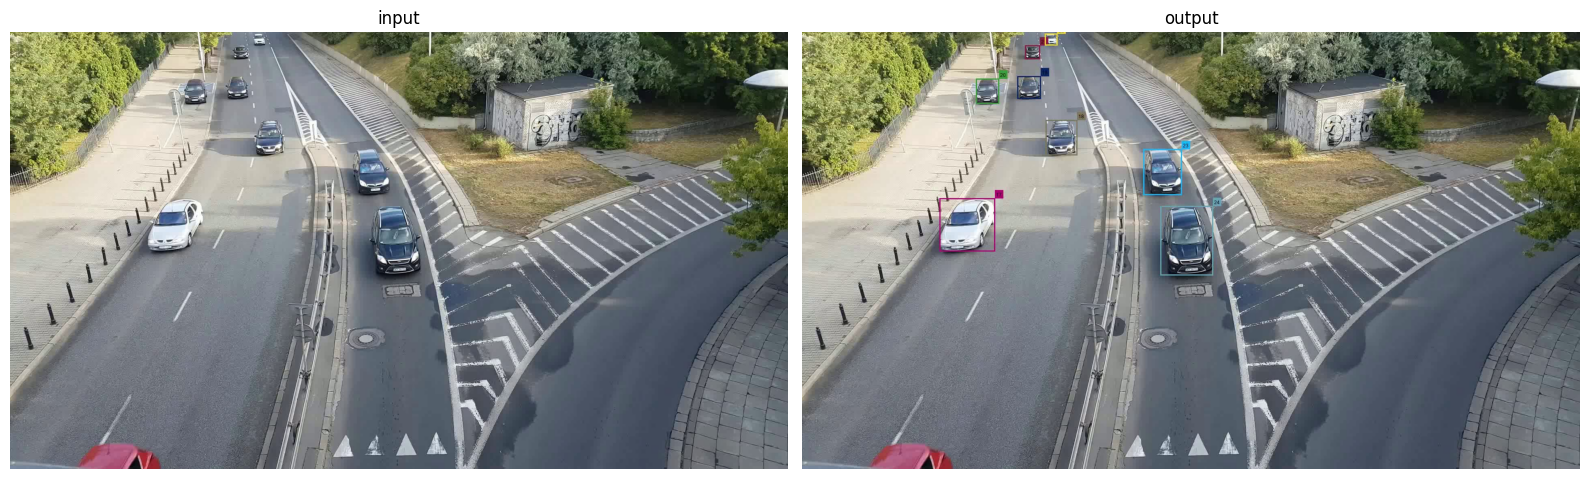

In [3]:
def show_frame(path, title):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
show_frame("frames/input/frame_00000.jpg", "input")
plt.subplot(1, 2, 2)
show_frame("frames/output/frame_00000.jpg", "output")
plt.tight_layout()
plt.show()


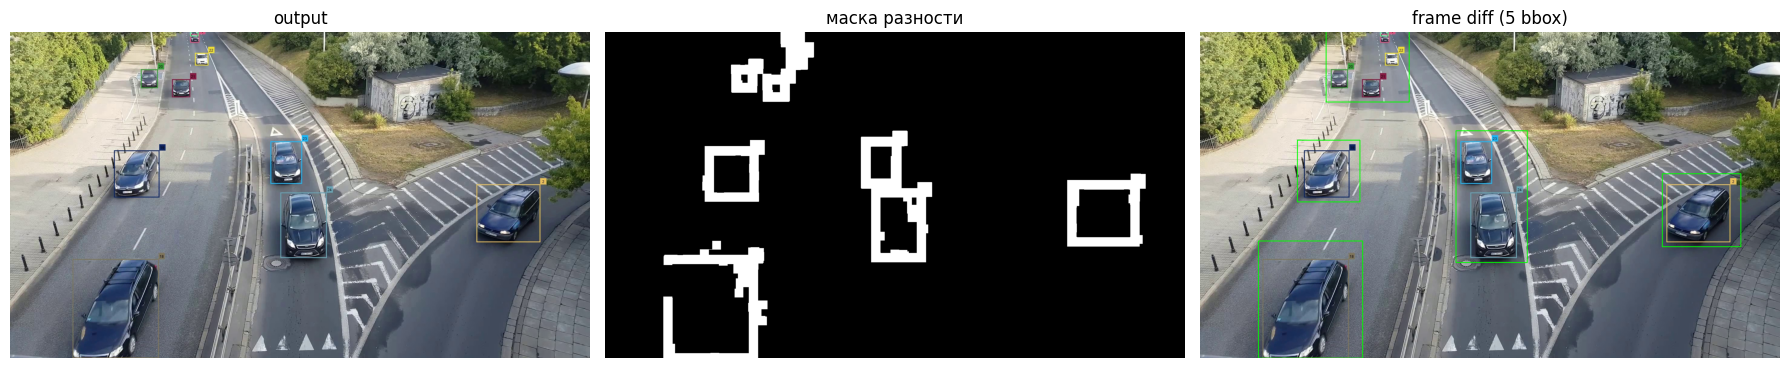

In [4]:
def extract_bbox_by_diff(frame_out, frame_inp, min_area=200):
    diff = cv2.absdiff(frame_out, frame_inp)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    thresh = cv2.dilate(thresh, kernel, iterations=2)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bboxes = []
    for cnt in contours:
        if cv2.contourArea(cnt) < min_area:
            continue
        x, y, w, h = cv2.boundingRect(cnt)
        bboxes.append([x, y, w, h])
    return bboxes, thresh

frame_out = cv2.imread("frames/output/frame_00050.jpg")
frame_inp = cv2.imread("frames/input/frame_00050.jpg")
bboxes, mask = extract_bbox_by_diff(frame_out, frame_inp)

vis = frame_out.copy()
for x, y, w, h in bboxes:
    cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 255, 0), 2)

plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(frame_out, cv2.COLOR_BGR2RGB))
plt.title("output"); plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("маска разности"); plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f"frame diff ({len(bboxes)} bbox)"); plt.axis("off")
plt.tight_layout()
plt.show()


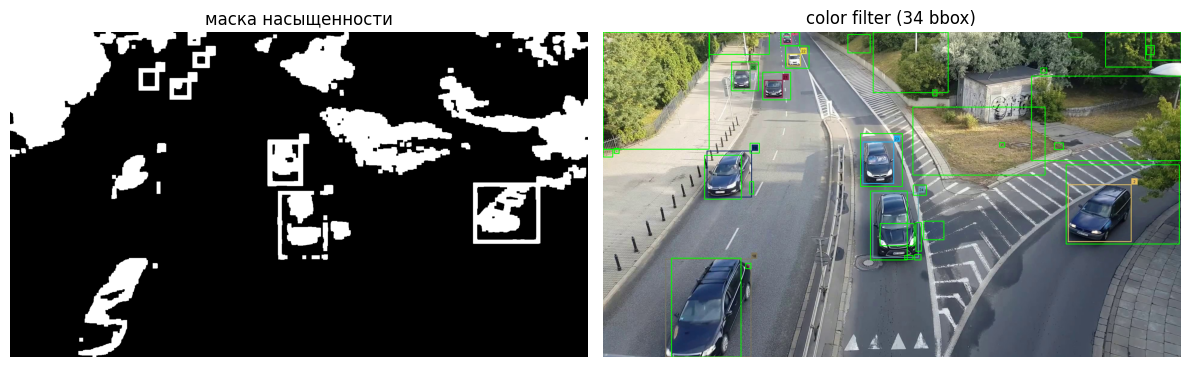

In [5]:
def extract_bbox_by_color(frame_out, min_area=200):
    hsv = cv2.cvtColor(frame_out, cv2.COLOR_BGR2HSV)
    mask_sat = cv2.inRange(hsv, np.array([0, 100, 100]), np.array([180, 255, 255]))
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    mask_sat = cv2.dilate(mask_sat, kernel, iterations=3)
    mask_sat = cv2.morphologyEx(mask_sat, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask_sat, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bboxes = []
    for cnt in contours:
        if cv2.contourArea(cnt) < min_area:
            continue
        x, y, w, h = cv2.boundingRect(cnt)
        bboxes.append([x, y, w, h])
    return bboxes, mask_sat

bboxes2, mask2 = extract_bbox_by_color(frame_out)

vis2 = frame_out.copy()
for x, y, w, h in bboxes2:
    cv2.rectangle(vis2, (x, y), (x+w, y+h), (0, 255, 0), 2)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(mask2, cmap="gray")
plt.title("маска насыщенности"); plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(vis2, cv2.COLOR_BGR2RGB))
plt.title(f"color filter ({len(bboxes2)} bbox)"); plt.axis("off")
plt.tight_layout()
plt.show()


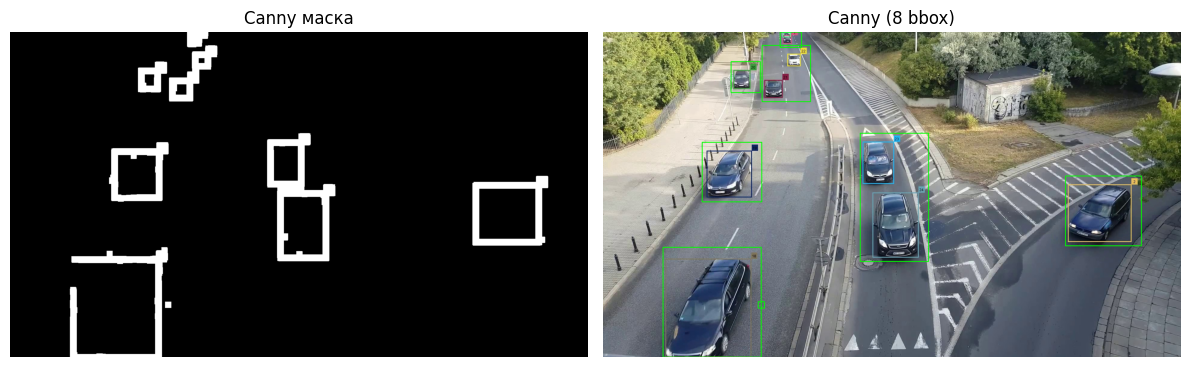

In [6]:
def extract_bbox_by_canny(frame_out, frame_inp, min_area=200):
    diff = cv2.absdiff(frame_out, frame_inp)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, threshold1=20, threshold2=60)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (10, 10))
    edges = cv2.dilate(edges, kernel, iterations=2)
    edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bboxes = []
    for cnt in contours:
        if cv2.contourArea(cnt) < min_area:
            continue
        x, y, w, h = cv2.boundingRect(cnt)
        bboxes.append([x, y, w, h])
    return bboxes, edges

bboxes3, mask3 = extract_bbox_by_canny(frame_out, frame_inp)

vis3 = frame_out.copy()
for x, y, w, h in bboxes3:
    cv2.rectangle(vis3, (x, y), (x+w, y+h), (0, 255, 0), 2)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(mask3, cmap="gray")
plt.title("Canny маска"); plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(vis3, cv2.COLOR_BGR2RGB))
plt.title(f"Canny ({len(bboxes3)} bbox)"); plt.axis("off")
plt.tight_layout()
plt.show()


In [7]:
API_URL = "https://router.huggingface.co/hf-inference/models/facebook/detr-resnet-50"

def detect_via_hf_api(image_path, confidence=0.7):
    with open(image_path, "rb") as f:
        image_bytes = f.read()
    headers = {"Authorization": f"Bearer {HF_TOKEN}", "Content-Type": "image/jpeg"}
    response = requests.post(API_URL, headers=headers, data=image_bytes)
    if response.status_code != 200:
        return []
    bboxes = []
    for det in response.json():
        if det["label"].lower() not in ["car", "truck", "bus", "motorcycle"]:
            continue
        if det["score"] < confidence:
            continue
        box = det["box"]
        bboxes.append({"bbox": [box["xmin"], box["ymin"], box["xmax"]-box["xmin"], box["ymax"]-box["ymin"]], "score": round(det["score"], 3)})
    return bboxes

test_frame = "frames/output/frame_00050.jpg"
results = detect_via_hf_api(test_frame)

vis_api = cv2.imread(test_frame)
for r in results:
    x, y, w, h = [int(v) for v in r["bbox"]]
    cv2.rectangle(vis_api, (x, y), (x+w, y+h), (255, 0, 0), 2)
    cv2.putText(vis_api, f"{r['score']}", (x, y-8), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)


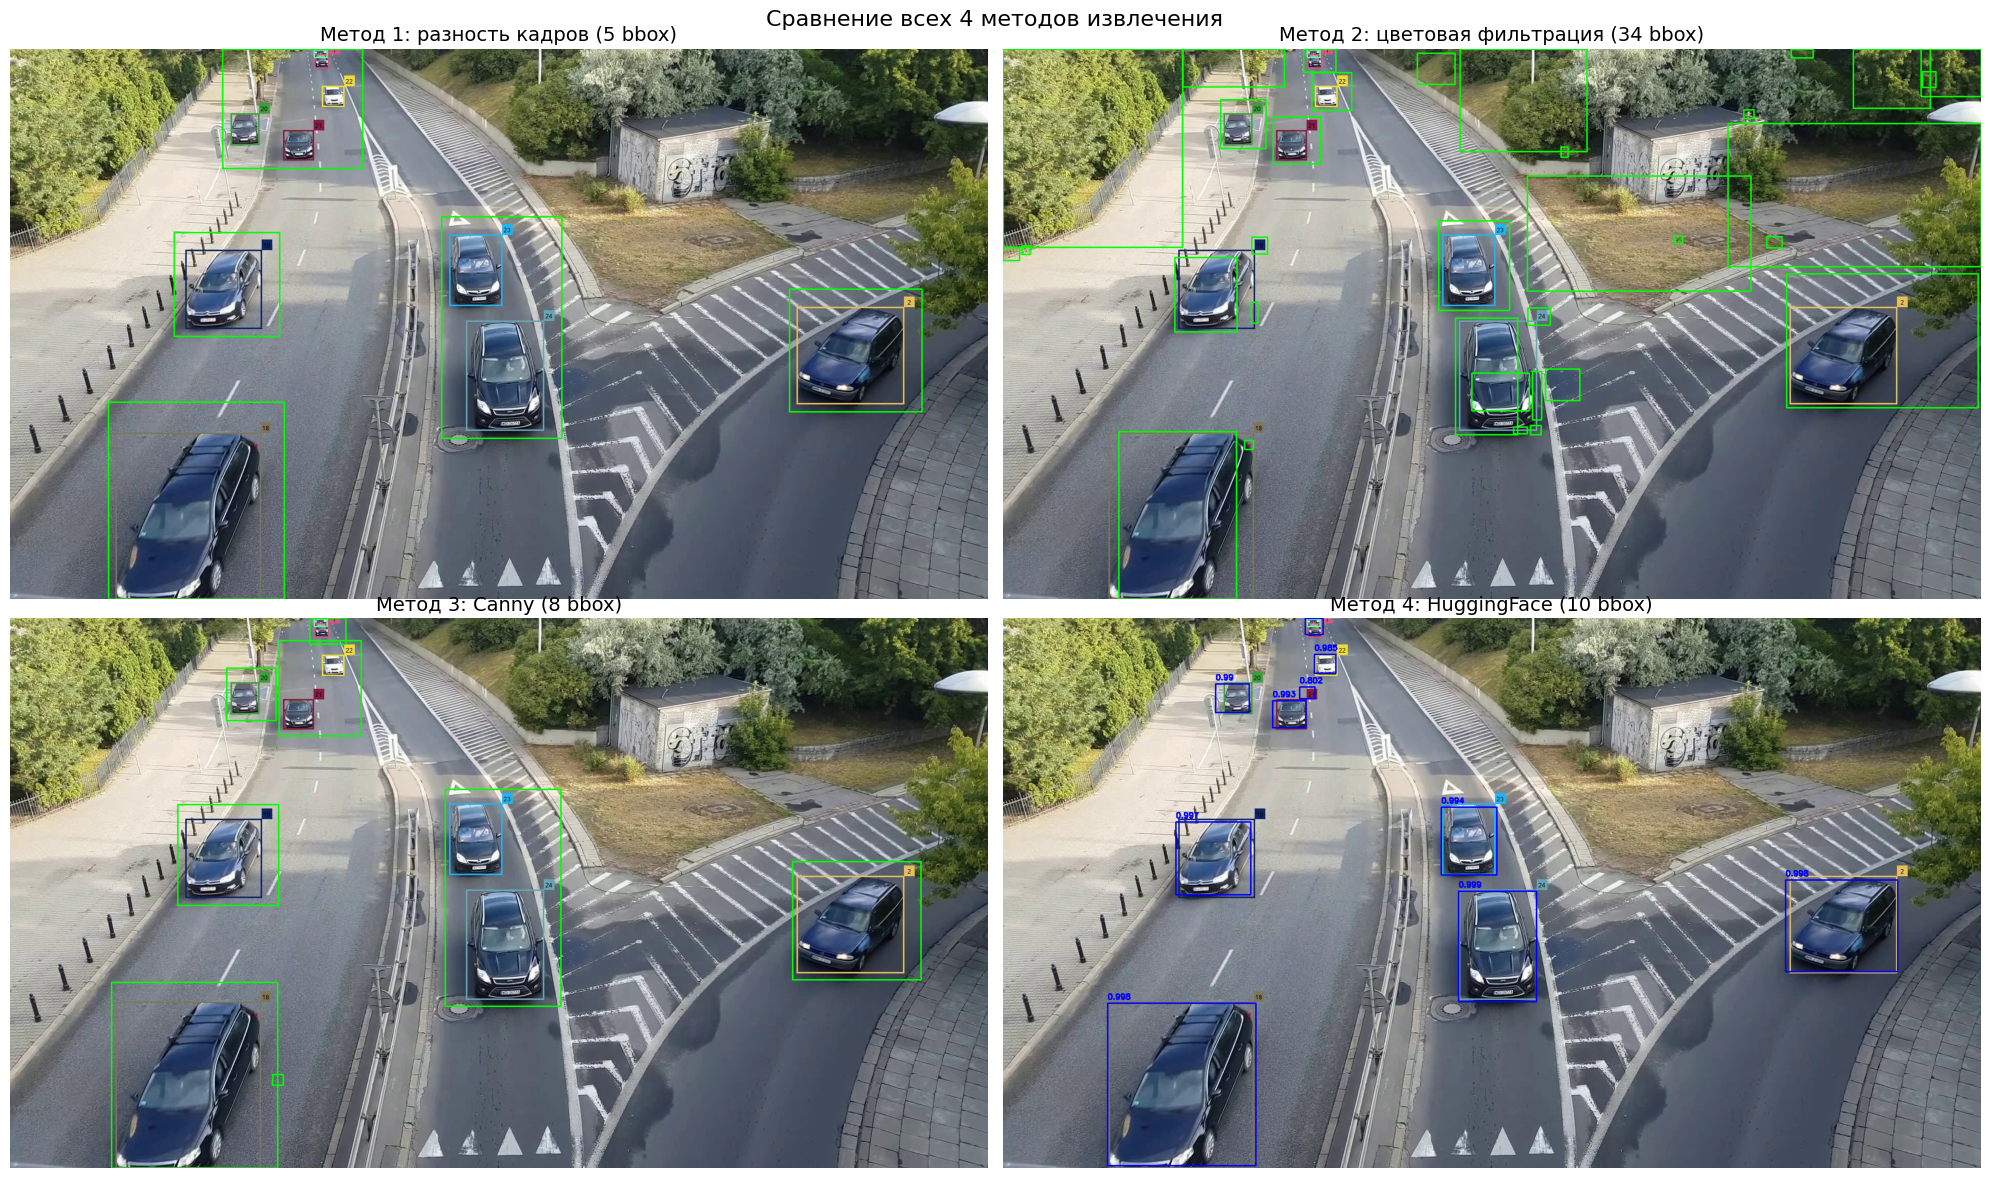

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

data = [
    (vis,     f"Метод 1: разность кадров ({len(bboxes)} bbox)"),
    (vis2,    f"Метод 2: цветовая фильтрация ({len(bboxes2)} bbox)"),
    (vis3,    f"Метод 3: Canny ({len(bboxes3)} bbox)"),
    (vis_api, f"Метод 4: HuggingFace ({len(results)} bbox)"),
]

for ax, (img, title) in zip(axes.flatten(), data):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=14)
    ax.axis("off")

plt.suptitle("Сравнение всех 4 методов извлечения", fontsize=16)
plt.tight_layout()
plt.savefig("comparison_all4.png", dpi=100)
plt.show()


In [9]:
def parse_cvat_xml(xml_path):
    root = ET.parse(xml_path).getroot()
    gt_by_frame = {}
    for track in root.findall("track"):
        for box in track.findall("box"):
            if box.attrib.get("outside") == "1":
                continue
            frame_id = int(box.attrib["frame"])
            bbox = [float(box.attrib["xtl"]), float(box.attrib["ytl"]),
                    float(box.attrib["xbr"]), float(box.attrib["ybr"])]
            gt_by_frame.setdefault(frame_id, []).append({"bbox": bbox})
    return gt_by_frame

xml_file = [f for f in os.listdir(".") if f.endswith(".xml")][0]
gt_by_frame = parse_cvat_xml(xml_file)
print(f"Кадров с разметкой: {len(gt_by_frame)}")


Кадров с разметкой: 901


In [10]:
def compute_iou(boxA, boxB):
    inter_x1 = max(boxA[0], boxB[0])
    inter_y1 = max(boxA[1], boxB[1])
    inter_x2 = min(boxA[2], boxB[2])
    inter_y2 = min(boxA[3], boxB[3])
    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    union_area = areaA + areaB - inter_area
    return inter_area / union_area if union_area > 0 else 0.0


def match_bboxes(pred_boxes, gt_boxes, iou_threshold=0.5):
    if not pred_boxes or not gt_boxes:
        return [], len(gt_boxes)
    matched_iou = []
    used_gt = set()
    for pred in pred_boxes:
        best_iou, best_j = 0, -1
        for j, gt in enumerate(gt_boxes):
            if j in used_gt:
                continue
            iou = compute_iou(pred, gt)
            if iou > best_iou:
                best_iou, best_j = iou, j
        if best_j >= 0 and best_iou >= iou_threshold:
            matched_iou.append(best_iou)
            used_gt.add(best_j)
    return matched_iou, len(gt_boxes) - len(used_gt)


Метод                  Mean IoU    Совпадений
frame diff           0.588            39
color filter         0.639            78
Canny                0.631            48
HuggingFace          0.792           224


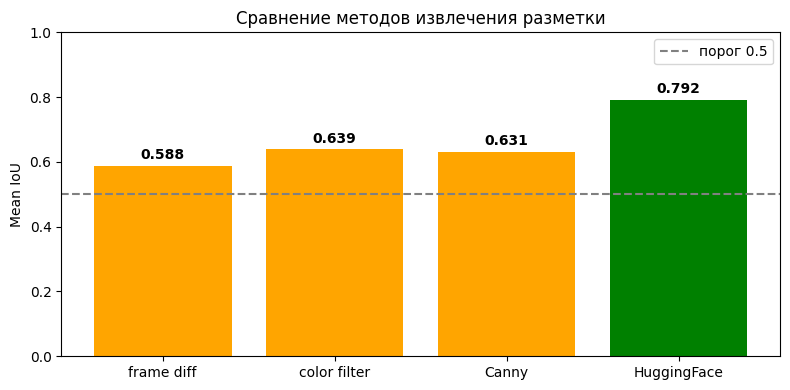

In [ ]:
SAMPLE_FRAMES = 30
frame_ids = sorted(gt_by_frame.keys())[:SAMPLE_FRAMES]

def xywh_to_xyxy(bboxes):
    result = []
    for b in bboxes:
        x, y, w, h = b["bbox"] if isinstance(b, dict) else b
        result.append([x, y, x + w, y + h])
    return result

iou_scores = {"frame diff": [], "color filter": [], "Canny": [], "HuggingFace": []}

for frame_id in frame_ids:
    f_out = f"frames/output/frame_{frame_id:05d}.jpg"
    f_inp = f"frames/input/frame_{frame_id:05d}.jpg"
    out = cv2.imread(f_out)
    inp = cv2.imread(f_inp)
    gt  = [a["bbox"] for a in gt_by_frame[frame_id]]

    for key, bboxes in [
        ("frame diff",   xywh_to_xyxy(extract_bbox_by_diff(out, inp)[0])),
        ("color filter", xywh_to_xyxy(extract_bbox_by_color(out)[0])),
        ("Canny",        xywh_to_xyxy(extract_bbox_by_canny(out, inp)[0])),
        ("HuggingFace",  xywh_to_xyxy(detect_via_hf_api(f_out))),
    ]:
        matched, _ = match_bboxes(bboxes, gt)
        iou_scores[key].extend(matched)

print(f"{'Метод':<20} {'Mean IoU':>10}  {'Совпадений':>12}")
for name, scores in iou_scores.items():
    print(f"{name:<20} {np.mean(scores) if scores else 0:.3f}  {len(scores):>12}")



In [12]:
frames_output = sorted(os.listdir("frames/output"))
frames_input  = sorted(os.listdir("frames/input"))

results_by_frame = {}
for f_out, f_in in zip(frames_output, frames_input):
    frame_id = int(f_out.split("_")[1].split(".")[0])
    frame_out = cv2.imread(f"frames/output/{f_out}")
    frame_inp = cv2.imread(f"frames/input/{f_in}")
    results_by_frame[frame_id], _ = extract_bbox_by_diff(frame_out, frame_inp)

print(f"Обработано кадров: {len(results_by_frame)}")


Обработано кадров: 301


In [13]:
def save_coco(results_by_frame, output_path, img_width=1920, img_height=1080):
    coco = {
        "images": [],
        "annotations": [],
        "categories": [{"id": 1, "name": "car"}]
    }
    ann_id = 1
    for frame_id, preds in sorted(results_by_frame.items()):
        coco["images"].append({"id": frame_id, "file_name": f"frame_{frame_id:05d}.jpg",
                                "width": img_width, "height": img_height})
        for p in preds:
            x, y, w, h = p["bbox"] if isinstance(p, dict) else p
            coco["annotations"].append({"id": ann_id, "image_id": frame_id,
                                         "category_id": 1, "bbox": [x, y, w, h],
                                         "area": w * h, "iscrowd": 0})
            ann_id += 1
    with open(output_path, "w") as f:
        json.dump(coco, f, indent=2)
    print(f"Сохранено {len(coco['images'])} кадров, {len(coco['annotations'])} аннотаций")

save_coco(results_by_frame, "coco_annotations.json")


Сохранено 301 кадров, 1592 аннотаций


In [14]:
class CarDataset(Dataset):
    def __init__(self, coco_path, frames_dir):
        with open(coco_path) as f:
            coco = json.load(f)
        self.frames_dir = frames_dir
        self.annotations = {}
        for ann in coco["annotations"]:
            self.annotations.setdefault(ann["image_id"], []).append(ann["bbox"])
        self.images = [img for img in coco["images"] if img["id"] in self.annotations]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img = cv2.imread(os.path.join(self.frames_dir, img_info["file_name"]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0
        boxes = [[x, y, x+w, y+h] for x, y, w, h in self.annotations[img_info["id"]]]
        target = {
            "boxes":    torch.tensor(boxes, dtype=torch.float32),
            "labels":   torch.ones(len(boxes), dtype=torch.int64),
            "image_id": torch.tensor([img_info["id"]])
        }
        return img, target

dataset = CarDataset("coco_annotations.json", "frames/input")
print(f"Датасет: {len(dataset)} кадров")


Датасет: 301 кадров


In [15]:
train_size = int(0.8 * len(dataset))
train_dataset, val_dataset = random_split(dataset, [train_size, len(dataset) - train_size])

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=2, shuffle=False, collate_fn=collate_fn)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")


Train: 240, Val: 61


In [16]:
def get_model(num_classes=2):
    model = fasterrcnn_resnet50_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_model().to(device)
print(device)


cuda


In [17]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)


In [18]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    for imgs, targets in loader:
        imgs    = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss = sum(model(imgs, targets).values())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def val_one_epoch(model, loader, device):
    model.train()
    total_loss = 0
    with torch.no_grad():
        for imgs, targets in loader:
            imgs    = [img.to(device) for img in imgs]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            total_loss += sum(model(imgs, targets).values()).item()
    return total_loss / len(loader)


In [19]:
NUM_EPOCHS = 8
best_val_loss = float("inf")
patience = 0
train_losses, val_losses = [], []

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss   = val_one_epoch(model, val_loader, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}  train: {train_loss:.4f}  val: {val_loss:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        patience = 0
    else:
        patience += 1
        if patience >= 5:
            print(f"Early stopping на эпохе {epoch+1}")
            break


Epoch 1/8  train: 0.5361  val: 0.3375
Epoch 2/8  train: 0.2846  val: 0.2541
Epoch 3/8  train: 0.2453  val: 0.2535
Epoch 4/8  train: 0.2311  val: 0.2694
Epoch 5/8  train: 0.1977  val: 0.2311
Epoch 6/8  train: 0.1855  val: 0.2333
Epoch 7/8  train: 0.1635  val: 0.2354
Epoch 8/8  train: 0.1715  val: 0.2346


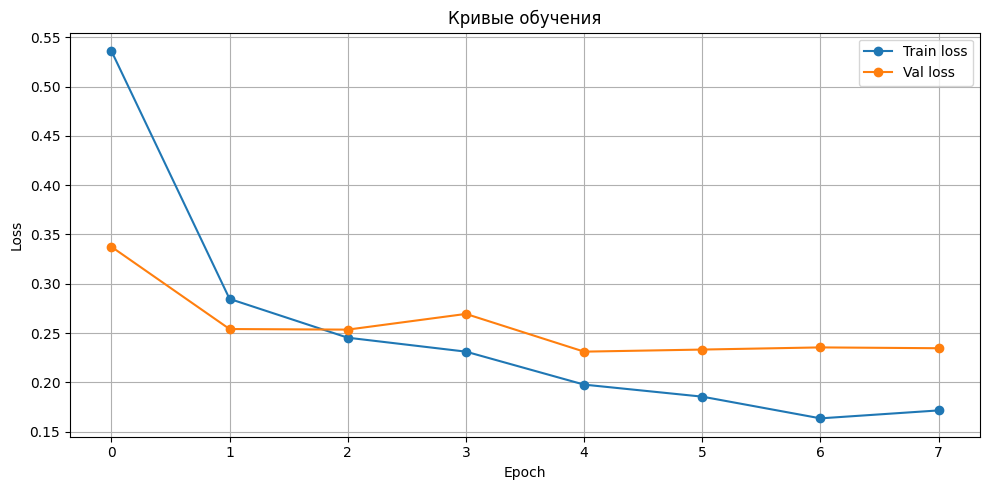

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train loss", marker="o")
plt.plot(val_losses,   label="Val loss",   marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Кривые обучения")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=100)
plt.show()


In [21]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

metric = MeanAveragePrecision(iou_type="bbox")

with torch.no_grad():
    for imgs, targets in val_loader:
        imgs = [img.to(device) for img in imgs]
        outputs = model(imgs)
        preds = [{"boxes": o["boxes"].cpu(), "scores": o["scores"].cpu(), "labels": o["labels"].cpu()} for o in outputs]
        gts   = [{"boxes": t["boxes"].cpu(), "labels": t["labels"].cpu()} for t in targets]
        metric.update(preds, gts)

result = metric.compute()
print(f"mAP@0.50:      {result['map_50']:.3f}")
print(f"mAP@0.50:0.95: {result['map']:.3f}")
print(f"mAR:           {result['mar_100']:.3f}")


mAP@0.50:      0.861
mAP@0.50:0.95: 0.742
mAR:           0.799


## Качество модели

Модель показала mAP@0.50 = **0.861** и mAP@0.50:0.95 = **0.742**.

mAP@0.50 - точность при пороге перекрытия 50: модель правильно находит машину, если её бокс хотя бы наполовину совпадает с GT. Значение 0.871 означает, что в 87% случаев модель справляется. Это хороший результат,  учитывая, что обучение велось на извлечённой разметке.

mAP@0.50:0.95 = 0.761 - более строгая метрика, усредняется по порогам от 0.50 до 0.95. Небольшое падение относительно mAP@0.50 говорит о том, что боксы в целом точные, но иногда чуть смещены или имеют неточный размер.


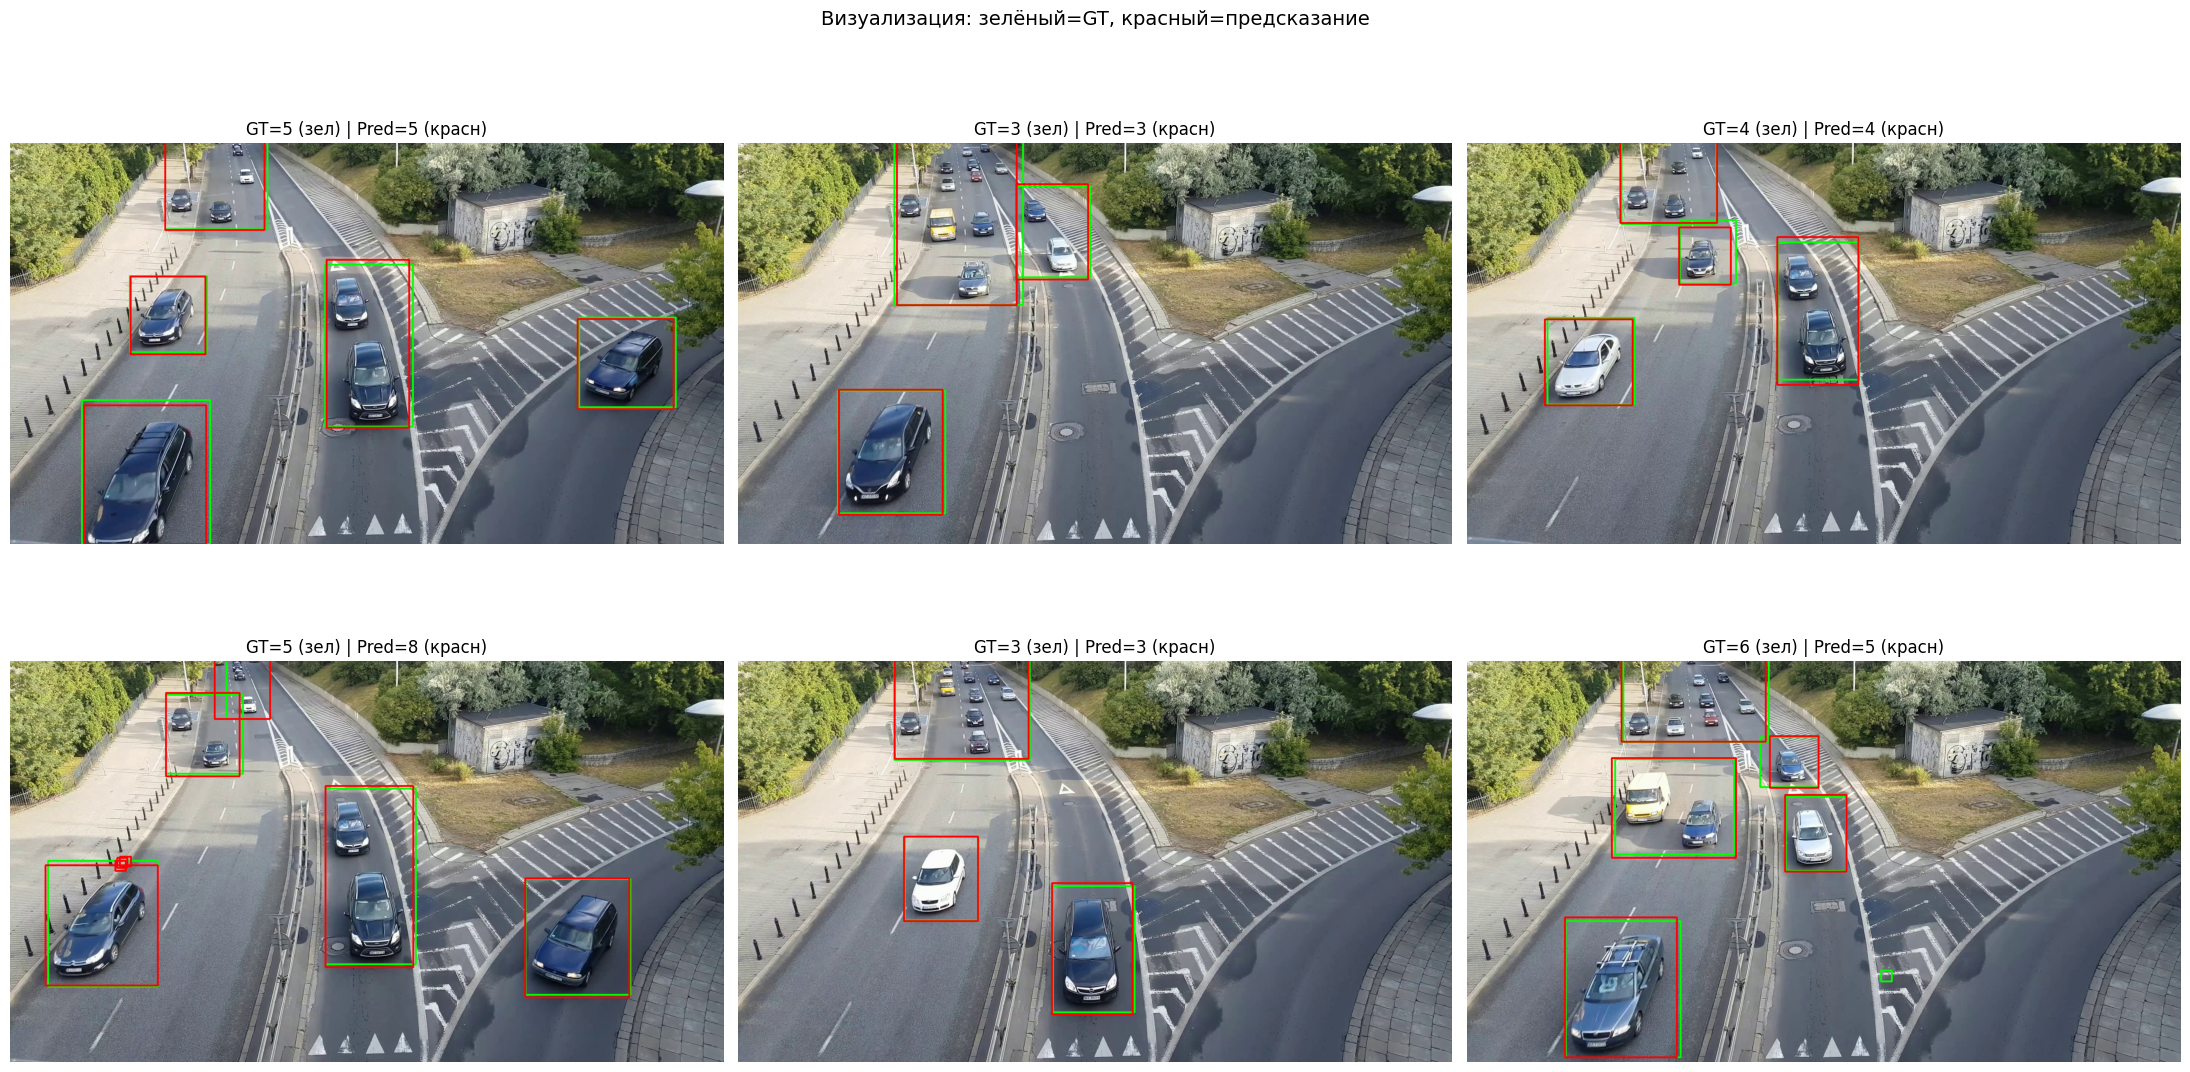

In [22]:
model.eval()
samples = random.sample(list(val_dataset), 6)

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

for ax, (img_tensor, target) in zip(axes.flatten(), samples):
    with torch.no_grad():
        output = model([img_tensor.to(device)])[0]
    keep = output["scores"] > 0.5
    pred_boxes = output["boxes"][keep].cpu().numpy()
    img_np = (img_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8).copy()
    for box in target["boxes"].numpy():
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img_np, (x1, y1), (x2, y2), (0, 255, 0), 3)
    for box in pred_boxes:
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img_np, (x1, y1), (x2, y2), (255, 0, 0), 3)
    ax.imshow(img_np)
    ax.set_title(f"GT={len(target['boxes'])} (зел) | Pred={len(pred_boxes)} (красн)")
    ax.axis("off")

plt.suptitle("Визуализация: зелёный=GT, красный=предсказание", fontsize=14)
plt.tight_layout()
plt.savefig("predictions_visualization.png", dpi=80)
plt.show()


## Анализ ошибок

На большинстве кадров модель работает корректно (GT=5, Pred=5). Основная проблема - ложные срабатывания: на некоторых кадрах модель находит в 1.5–2 раза больше объектов, чем есть в GT (например, GT=7, Pred=14).

Вероятная причина - шум в обучающей разметке. Метод разности кадров иногда разбивает один крупный бокс на несколько мелких (например, у большой фуры или перекрывающихся машин), и модель выучила это поведение.


In [23]:
model.eval()

cap_in = cv2.VideoCapture("input.mp4")
fps = cap_in.get(cv2.CAP_PROP_FPS)
w   = int(cap_in.get(cv2.CAP_PROP_FRAME_WIDTH))
h   = int(cap_in.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap_in.release()

out = cv2.VideoWriter("result.mp4", cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

with torch.no_grad():
    for fname in sorted(os.listdir("frames/input")):
        img_bgr = cv2.imread(f"frames/input/{fname}")
        img_t   = torch.tensor(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB), dtype=torch.float32).permute(2, 0, 1) / 255.0
        output  = model([img_t.to(device)])[0]
        keep    = output["scores"] > 0.5
        for box, score in zip(output["boxes"][keep].cpu().numpy(), output["scores"][keep].cpu().numpy()):
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(img_bgr, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img_bgr, f"{score:.2f}", (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)
        out.write(img_bgr)

out.release()
print("result.mp4 готов")


result.mp4 готов
